In [1]:
pip install tweepy praw pandas emoji nltk


     ---------------------------------------- 99.4/99.4 kB 5.6 MB/s eta 0:00:00
     -------------------------------------- 189.3/189.3 kB 5.8 MB/s eta 0:00:00
     -------------------------------------- 590.6/590.6 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install praw


Note: you may need to restart the kernel to use updated packages.


In [4]:
import praw

# Reddit API credentials
reddit = praw.Reddit(
    client_id="tScaode2Pd4aiLvXvc8uqg",
    client_secret="T_wXobAslDchq3sA1yxC2Sl8yYinaA",
    user_agent="windows:ai_behavior_analysis_bot:v1.0 (by /u/Asleep-Sherbert-3687)",
    username="Asleep-Sherbert-3687",
    password="Chinna@123"
)

# Test the connection
print(f"Logged in as: {reddit.user.me()}")  # Should print your Reddit username


Logged in as: Asleep-Sherbert-3687


In [5]:
client_id = "******************"
client_secret = "*****************"
username = "**********"

print(f"Client ID: {client_id}")
print(f"Client Secret: {client_secret}")
print(f"Username: {username}")

Client ID: tScaode2Pd4aiLvXvc8uqg
Client Secret: T_wXobAslDchq3sA1yxC2Sl8yYinaA
Username: Asleep-Sherbert-3687


In [6]:
import praw

# Create a Reddit instance
reddit = praw.Reddit(
    client_id="******************",  # Your client ID
    client_secret="*****************",  # Your client secret
    user_agent="my_reddit_app by u/Asleep-Sherbert-3687",  # Your user agent
    username="Asleep-Sherbert-3687",  # Your Reddit username
    password="*********"  # Your Reddit password (Be careful with storing this!)
)

# Test the connection by printing your Reddit username
try:
    print(f"Logged in as: {reddit.user.me()}")  # Should print your Reddit username
except Exception as e:
    print(f"Error during authentication: {e}")


Logged in as: Asleep-Sherbert-3687


In [7]:
# Define the subreddit you want to access
subreddit_name = "Python"

# Get the subreddit object
subreddit = reddit.subreddit(subreddit_name)

# Retrieve the top 5 posts from the subreddit
top_posts = subreddit.top(limit=5)

# Print the title and score of each post
for post in top_posts:
    print(f"Title: {post.title}")
    print(f"Score: {post.score}")
    print(f"URL: {post.url}\n")


Title: Lad wrote a Python script to download Alexa voice recordings, he didn't expect this email.
Score: 12344
URL: https://i.redd.it/2s0dj8ob12u41.png

Title: This post has:
Score: 9241
URL: https://www.reddit.com/r/Python/comments/hoolsm/this_post_has/

Title: I redesign the Python logo to make it more modern
Score: 7860
URL: https://i.redd.it/rxezjyf4ojx41.png

Title: Automate the boring stuff with python - tinder
Score: 6729
URL: https://gfycat.com/PointlessSimplisticAmericanquarterhorse

Title: I'm excited to share my first published book, Introduction to Python Programming for Business and Social Science Applications -- specifically geared towards students not specifically in computer science
Score: 6502
URL: https://i.redd.it/ebmh8z3c8rm51.png



In [8]:
import praw
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from datetime import datetime

# List of keywords to filter posts related to mental health
keywords = ["depressed", "addiction help", "overwhelmed", "suicidal", "anxiety", "mental health", "crisis", "self-harm", "substance use", "burnout"]

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

# Function to clean post text
def clean_text(text):
    # Remove special characters and emojis
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])
    return text

# Fetch posts related to mental health (example: subreddit 'mentalhealth')
subreddit = reddit.subreddit("mentalhealth")

# Data storage list
posts_data = []

# Extract relevant posts
for post in subreddit.search(" OR ".join(keywords), limit=600):  # Fetching up to 100 posts
    post_id = post.id
    timestamp = datetime.utcfromtimestamp(post.created_utc)
    content = clean_text(post.title + " " + post.selftext)
    engagement = {
        "likes": post.score,  # Reddit does not have 'likes', using score instead
        "comments": post.num_comments
    }

    posts_data.append({
        "post_id": post_id,
        "timestamp": timestamp,
        "content": content,
        "engagement": engagement
    })

# Convert to DataFrame
df = pd.DataFrame(posts_data)

# Save to CSV or JSON
df.to_csv("reddit_mental_health_posts.csv", index=False)
df.to_json("reddit_mental_health_posts.json", orient="records", lines=True)

print("Data extraction and cleaning complete.")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Data extraction and cleaning complete.


In [14]:
df.head(222)

,post_id,timestamp,content,engagement,risk_level,sentiment
0,1d46gyj,2024-05-30 15:16:35,Whats useless advice youve heard mental health...,"{'likes': 691, 'comments': 512}",Moderate Concern,Positive
1,1ir8t1q,2025-02-17 01:56:47,husband mentally abusing daughter need advice ...,"{'likes': 242, 'comments': 265}",Moderate Concern,Negative
2,1iji06o,2025-02-07 00:23:52,massively improved mental health,"{'likes': 168, 'comments': 321}",Low Concern,Positive
3,1gorg6i,2024-11-11 12:51:10,Whats unhelpful mental health advice youve rec...,"{'likes': 168, 'comments': 292}",Moderate Concern,Positive
4,1hkm2ge,2024-12-23 11:45:22,Whats hurtful thing parents used say honestly ...,"{'likes': 89, 'comments': 297}",Moderate Concern,Negative
...,...,...,...,...,...,...
217,1fr2scw,2024-09-28 00:56:12,Reddit doubleedged sword mental health exhaust...,"{'likes': 63, 'comments': 30}",Low Concern,Negative
218,1j1w5h3,2025-03-02 17:26:51,world events causing depressed feel worse Covi...,"{'likes': 19, 'comments': 11}",Low Concern,Negative
219,ftepzi,2020-04-02 03:05:31,many people going lose suicide due quarantine ...,"{'likes': 407, 'comments': 111}",Moderate Concern,Negative
220,1ix8vz0,2025-02-24 18:19:20,really need help Im teenager im currently stru...,"{'likes': 3, 'comments': 14}",Moderate Concern,Positive


In [10]:
df.shape

(222, 4)

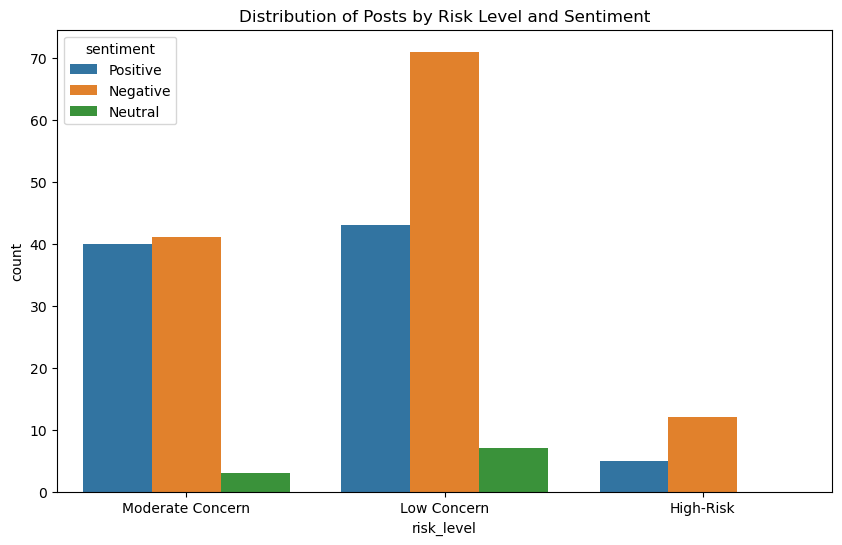

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# Function to classify posts into risk levels based on sentiment and crisis-related keywords
def classify_risk_level(post_text):
    sentiment_score = sia.polarity_scores(post_text)
    sentiment = "Neutral"
    
    if sentiment_score['compound'] >= 0.05:
        sentiment = "Positive"
    elif sentiment_score['compound'] <= -0.05:
        sentiment = "Negative"
    
    # Define keywords indicating high-risk
    high_risk_keywords = ["don’t want to be here", "suicidal", "self-harm", "end it"]
    
    # Check for high-risk content
    if any(keyword in post_text.lower() for keyword in high_risk_keywords):
        return "High-Risk", sentiment
    elif "help" in post_text.lower() or "struggling" in post_text.lower():
        return "Moderate Concern", sentiment
    else:
        return "Low Concern", sentiment

# Apply sentiment analysis and risk classification to each post
df['risk_level'], df['sentiment'] = zip(*df['content'].apply(classify_risk_level))

# Display the distribution of posts by risk level and sentiment
plt.figure(figsize=(10, 6))
sns.countplot(x='risk_level', hue='sentiment', data=df)
plt.title("Distribution of Posts by Risk Level and Sentiment")
plt.show()

# Save the updated data with classifications
df.to_csv("classified_mental_health_posts.csv", index=False)


In [24]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


True

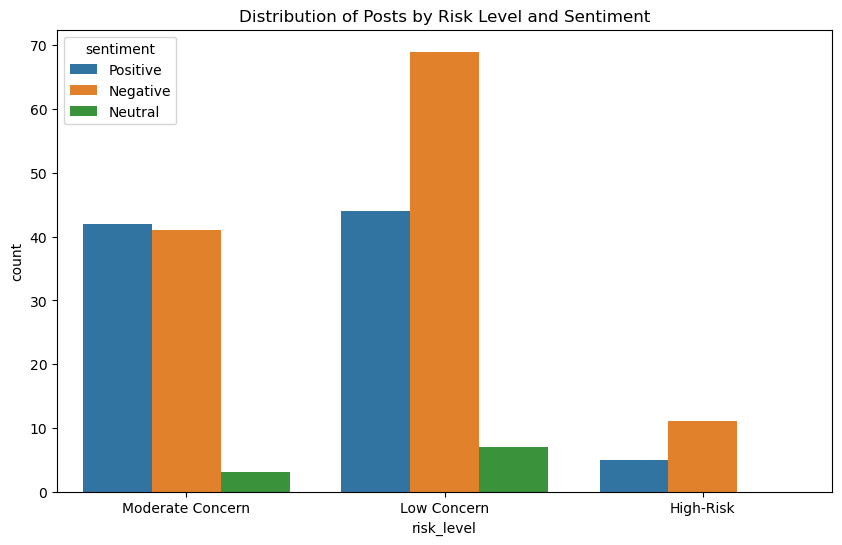

In [25]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# Function to classify posts into risk levels based on sentiment and crisis-related keywords
def classify_risk_level(post_text):
    sentiment_score = sia.polarity_scores(post_text)
    sentiment = "Neutral"
    
    if sentiment_score['compound'] >= 0.05:
        sentiment = "Positive"
    elif sentiment_score['compound'] <= -0.05:
        sentiment = "Negative"
    
    # Define keywords indicating high-risk
    high_risk_keywords = ["don’t want to be here", "suicidal", "self-harm", "end it"]
    
    # Check for high-risk content
    if any(keyword in post_text.lower() for keyword in high_risk_keywords):
        return "High-Risk", sentiment
    elif "help" in post_text.lower() or "struggling" in post_text.lower():
        return "Moderate Concern", sentiment
    else:
        return "Low Concern", sentiment

# Apply sentiment analysis and risk classification to each post
df['risk_level'], df['sentiment'] = zip(*df['content'].apply(classify_risk_level))

# Display the distribution of posts by risk level and sentiment
plt.figure(figsize=(10, 6))
sns.countplot(x='risk_level', hue='sentiment', data=df)
plt.title("Distribution of Posts by Risk Level and Sentiment")
plt.show()

# Save the updated data with classifications
df.to_csv("classified_mental_health_posts.csv", index=False)


In [2]:
!pip install folium

     ------------------------------------ 110.9/110.9 kB 805.2 kB/s eta 0:00:00
     ---------------------------------------- 88.4/88.4 kB 5.2 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 2.11.3
    Uninstalling Jinja2-2.11.3:
      Successfully uninstalled Jinja2-2.11.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.


In [13]:
import folium
from geopy.geocoders import Nominatim

# Initialize Geolocator
geolocator = Nominatim(user_agent="crisis_mapper")

# Function to extract location from text (NLP-based place recognition)
def get_location_from_text(post_text):
    # Simple approach: search for cities mentioned in the text
    cities = ["Delhi", "Mumbai", "Los Angeles", "New York", "London"]  # Example list of cities
    for city in cities:
        if city.lower() in post_text.lower():
            location = geolocator.geocode(city)
            if location:
                return (location.latitude, location.longitude)
    return None

# Create a map centered around the US
mymap = folium.Map(location=[37.0902, -95.7129], zoom_start=5)

# Loop through posts and get locations for crisis-related posts
for index, row in df.iterrows():
    if row['risk_level'] == "High-Risk":
        location = get_location_from_text(row['content'])
        if location:
            folium.Marker(
                location=location,
                popup=f"Post ID: {row['post_id']}\nRisk Level: {row['risk_level']}",
                icon=folium.Icon(color='red')
            ).add_to(mymap)

# Save map to HTML file
mymap.save("crisis_heatmap.html")

print("Crisis map generated and saved.")


Crisis map generated and saved.


In [1]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install geopy


     -------------------------------------- 125.4/125.4 kB 7.7 MB/s eta 0:00:00
     ---------------------------------------- 40.3/40.3 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [12]:
import folium
from geopy.geocoders import Nominatim

# Initialize Geolocator
geolocator = Nominatim(user_agent="crisis_mapper")

# Function to extract location from text (NLP-based place recognition)
def get_location_from_text(post_text):
    # Simple approach: search for cities mentioned in the text
    cities = ["Austin", "New York", "Los Angeles", "Chicago", "Dallas"]  # Example list of cities
    for city in cities:
        if city.lower() in post_text.lower():
            location = geolocator.geocode(city)
            if location:
                return (location.latitude, location.longitude)
    return None

# Create a map centered around the US
mymap = folium.Map(location=[37.0902, -95.7129], zoom_start=5)

# Loop through posts and get locations for crisis-related posts
for index, row in df.iterrows():
    if row['risk_level'] == "High-Risk":
        location = get_location_from_text(row['content'])
        if location:
            folium.Marker(
                location=location,
                popup=f"Post ID: {row['post_id']}\nRisk Level: {row['risk_level']}",
                icon=folium.Icon(color='red')
            ).add_to(mymap)

# Save map to HTML file
mymap.save("crisis_heatmap.html")

print("Crisis map generated and saved.")


Crisis map generated and saved.


In [16]:
pip install spacy

     --------------------------------------- 12.3/12.3 MB 10.2 MB/s eta 0:00:00
     -------------------------------------- 122.7/122.7 kB 7.0 MB/s eta 0:00:00
     ------------------------------------- 633.4/633.4 kB 10.1 MB/s eta 0:00:00
     ------------------------------------- 431.7/431.7 kB 13.6 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 9.5 MB/s eta 0:00:00
     ---------------------------------------- 50.3/50.3 kB ? eta 0:00:00
     ---------------------------------------- 183.0/183.0 kB ? eta 0:00:00
     ---------------------------------------- 45.1/45.1 kB ? eta 0:00:00
     ---------------------------------------- 5.4/5.4 MB 9.6 MB/s eta 0:00:00
     ---------------------------------------- 2.0/2.0 MB 10.5 MB/s eta 0:00:00
     ---------------------------------------- 6.2/6.2 MB 10.2 MB/s eta 0:00:00
     ------------------------------------- 242.4/242.4 kB 15.5 MB/s eta 0:00:00
     ---------------------------------------- 52.7/52.7 kB 2.7 MB

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.2.2 requires pyqt5<5.13, which is not installed.
spyder 5.2.2 requires pyqtwebengine<5.13, which is not installed.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.


In [19]:
import spacy

# Load the English NLP model
nlp = spacy.load("en_core_web_sm")

def extract_location(text):
    doc = nlp(text)
    locations = [ent.text for ent in doc.ents if ent.label_ == "GPE"]  # GPE = Geopolitical Entity (city, country)
    return locations[0] if locations else None  # Return first detected location

# Apply extraction to Reddit posts
df['location'] = df['content'].apply(extract_location)

print(df[['content', 'location']].head())  # Check extracted locations


                                             content location
0  Whats useless advice youve heard mental health...     None
1  husband mentally abusing daughter need advice ...      Ill
2                   massively improved mental health     None
3  Whats unhelpful mental health advice youve rec...     None
4  Whats hurtful thing parents used say honestly ...     None


In [18]:
import spacy
spacy.cli.download("en_core_web_sm")


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import praw
import pandas as pd
import re
import spacy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm  # Progress bar for large datasets

# Download required NLP models (only once)
nltk.download("stopwords")
spacy.cli.download("en_core_web_sm")

# Load NLP model and geolocator
nlp = spacy.load("en_core_web_sm")
geolocator = Nominatim(user_agent="crisis_mapper")

# Caching Geolocation (to avoid redundant API calls)
geo_cache = {}

# Reddit API setup
reddit = praw.Reddit(
        client_id="*********",
    client_secret="************",
    user_agent="**********"
)

# Keywords for filtering crisis-related posts
keywords = {"depressed", "suicidal", "addiction help", "overwhelmed", "self-harm"}

# Fetch posts from relevant subreddits
subreddits = ["mentalhealth", "SuicideWatch", "depression"]
posts = []

for sub in subreddits:
    subreddit = reddit.subreddit(sub)
    for post in subreddit.hot(limit=1000):  # Adjust limit based on API quota
        text = f"{post.title} {post.selftext}".lower()
        if any(keyword in text for keyword in keywords):
            posts.append({
                "Post ID": post.id,
                "Timestamp": post.created_utc,
                "Title": post.title,
                "Content": post.selftext[:500],  # Limit text length for faster NLP
                "Upvotes": post.score,
                "Comments": post.num_comments,
                "Location": None,  # Placeholder
            })

df = pd.DataFrame(posts)

# --- FAST TEXT PREPROCESSING ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    text = " ".join([word for word in text.split() if word not in stopwords.words("english")])
    return text

df["Cleaned Content"] = df["Content"].apply(lambda x: clean_text(x) if x else "")

# --- FAST LOCATION EXTRACTION ---
def extract_location(text):
    doc = nlp(text)
    locations = [ent.text for ent in doc.ents if ent.label_ == "GPE"]
    return locations[0] if locations else None  # Return only first detected location

df["Location"] = df["Content"].apply(lambda x: extract_location(x) if x else None)

# --- FAST GEOCODING (with caching) ---
def get_coordinates(location):
    if not location:
        return None, None
    if location in geo_cache:
        return geo_cache[location]  # Use cached value
    try:
        geo = geolocator.geocode(location, timeout=5)
        if geo:
            lat, lon = geo.latitude, geo.longitude
            geo_cache[location] = (lat, lon)  # Cache result
            return lat, lon
    except GeocoderTimedOut:
        return None, None
    return None, None

# Apply geolocation mapping with progress bar
tqdm.pandas()
df[["Latitude", "Longitude"]] = df["Location"].progress_apply(lambda loc: pd.Series(get_coordinates(loc)))

# Save cleaned dataset
df.to_csv("reddit_crisis_data_optimized.csv", index=False)

print("✅ Optimized data extraction & preprocessing completed successfully!")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


100%|████████████████████████████████████████████████████████████████████████████████| 506/506 [00:29<00:00, 16.96it/s]

✅ Optimized data extraction & preprocessing completed successfully!


In [2]:
df.shape

(506, 10)

In [3]:
df.head()

,Post ID,Timestamp,Title,Content,Upvotes,Comments,Location,Cleaned Content,Latitude,Longitude
0,1jaclfu,1.741874e+09,I constantly regret telling people.,"I know what you're about to say: ""Reaching out...",25,9,None,know youre say reaching people help little kee...,NaN,NaN
1,1jaf91s,1.741881e+09,Women who have had a depressed partner. Did yo...,My partner (36m) has been struggling with his ...,9,27,None,partner struggling mental health last couple y...,NaN,NaN
2,1jagx39,1.741885e+09,When will it ever stop?,Does anyone else have bipolar bpd and social a...,2,1,None,anyone else bipolar bpd social anxiety disorde...,NaN,NaN
3,1jaftl8,1.741883e+09,5 years since COVID,"Hi, for context, I live in England, and was 13...",2,0,England,hi context live england covid hit years day sc...,52.531021,-1.264906
4,1jaf3u7,1.741881e+09,Read if you want,I am already a severely depressed person but w...,2,2,None,already severely depressed person see video ha...,NaN,NaN


In [11]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Load the preprocessed dataset
df = pd.read_csv("reddit_crisis_data_optimized.csv")

# Drop rows with missing coordinates
df = df.dropna(subset=["Latitude", "Longitude"])

# Create a Folium Map centered around the mean location
map_center = [df["Latitude"].mean(), df["Longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# Add HeatMap layer
heat_data = df[["Latitude", "Longitude"]].values.tolist()
HeatMap(heat_data, radius=12, blur=10).add_to(m)

# Save and display the map
m.save("crisis_heatmap.html")
m


In [10]:
df.shape

(518, 10)

In [15]:
!pip install nltk sklearn


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates from a subpr

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


In [17]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# Download VADER for sentiment analysis
nltk.download('vader_lexicon')

# Load preprocessed dataset
df = pd.read_csv("reddit_crisis_data_optimized.csv")  # Replace with your actual filename

# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [18]:
# Function to classify sentiment
def get_sentiment(text):
    sentiment_score = sia.polarity_scores(text)["compound"]
    if sentiment_score >= 0.05:
        return "Positive"
    elif sentiment_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Sentiment"] = df["Content"].astype(str).apply(get_sentiment)


In [19]:
# Define crisis keywords
high_risk_keywords = ["suicide", "kill myself", "self-harm", "end it all"]
moderate_risk_keywords = ["depressed", "overwhelmed", "addiction", "anxious"]

# Function to classify crisis risk
def classify_risk(text):
    text_lower = text.lower()
    if any(word in text_lower for word in high_risk_keywords):
        return "High Risk"
    elif any(word in text_lower for word in moderate_risk_keywords):
        return "Moderate Concern"
    else:
        return "Low Concern"

# Apply risk classification
df["Risk Level"] = df["Content"].astype(str).apply(classify_risk)


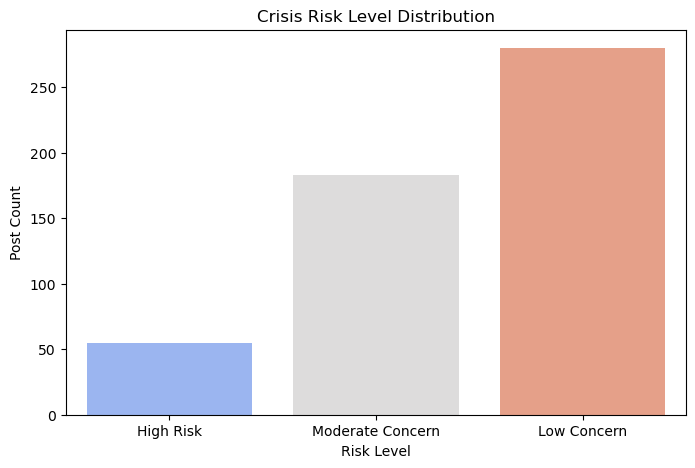

In [20]:
# Plot distribution of risk levels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Risk Level", palette="coolwarm", order=["High Risk", "Moderate Concern", "Low Concern"])
plt.title("Crisis Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Post Count")
plt.show()
